In [1]:
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ModuleNotFoundError: No module named 'cv2'

In [ ]:
import sys
!{sys.executable} -m pip install opencv-python pandas matplotlib

In [ ]:
data_dir = Path("../data")
raw_dir = data_dir / "raw"
annotated_dir = data_dir / "annotated"

df = pd.read_csv(annotated_dir / "ground_truth.csv")
print(f"Total receipts: {len(df)}")
print(df.head())

Total receipts: 17
         filename  amount        date                       store_branch  \
0  receipt_01.jpg    50.0  2026-05-10  7-Eleven Neribros Inc. Store#2006   
1  receipt_02.jpg   203.0  2026-05-10  7-Eleven Neribros Inc. Store#2006   
2  receipt_03.jpg    44.0  2026-05-10  7-Eleven Neribros Inc. Store#2006   
3  receipt_04.jpg    24.0  2026-05-11      7-Eleven Rhainella Store#2423   
4  receipt_05.jpg  1300.0  2026-05-10                    7-Connect Kiosk   

  condition  
0     fresh  
1     fresh  
2     fresh  
3     fresh  
4     fresh  


condition
fresh       8
faded       6
withered    3
Name: count, dtype: int64


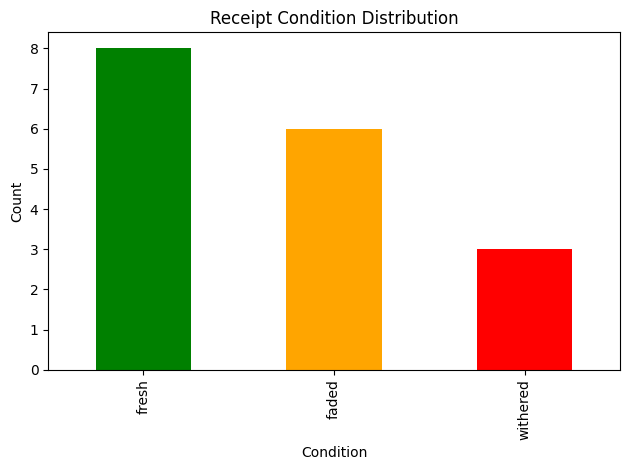

In [ ]:
condition_counts = df["condition"].value_counts()
print(condition_counts)

condition_counts.plot(kind="bar", color=["green", "orange", "red"])
plt.title("Receipt Condition Distribution")
plt.xlabel("Condition")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../outputs/figures/condition_distribution.png")
plt.show()

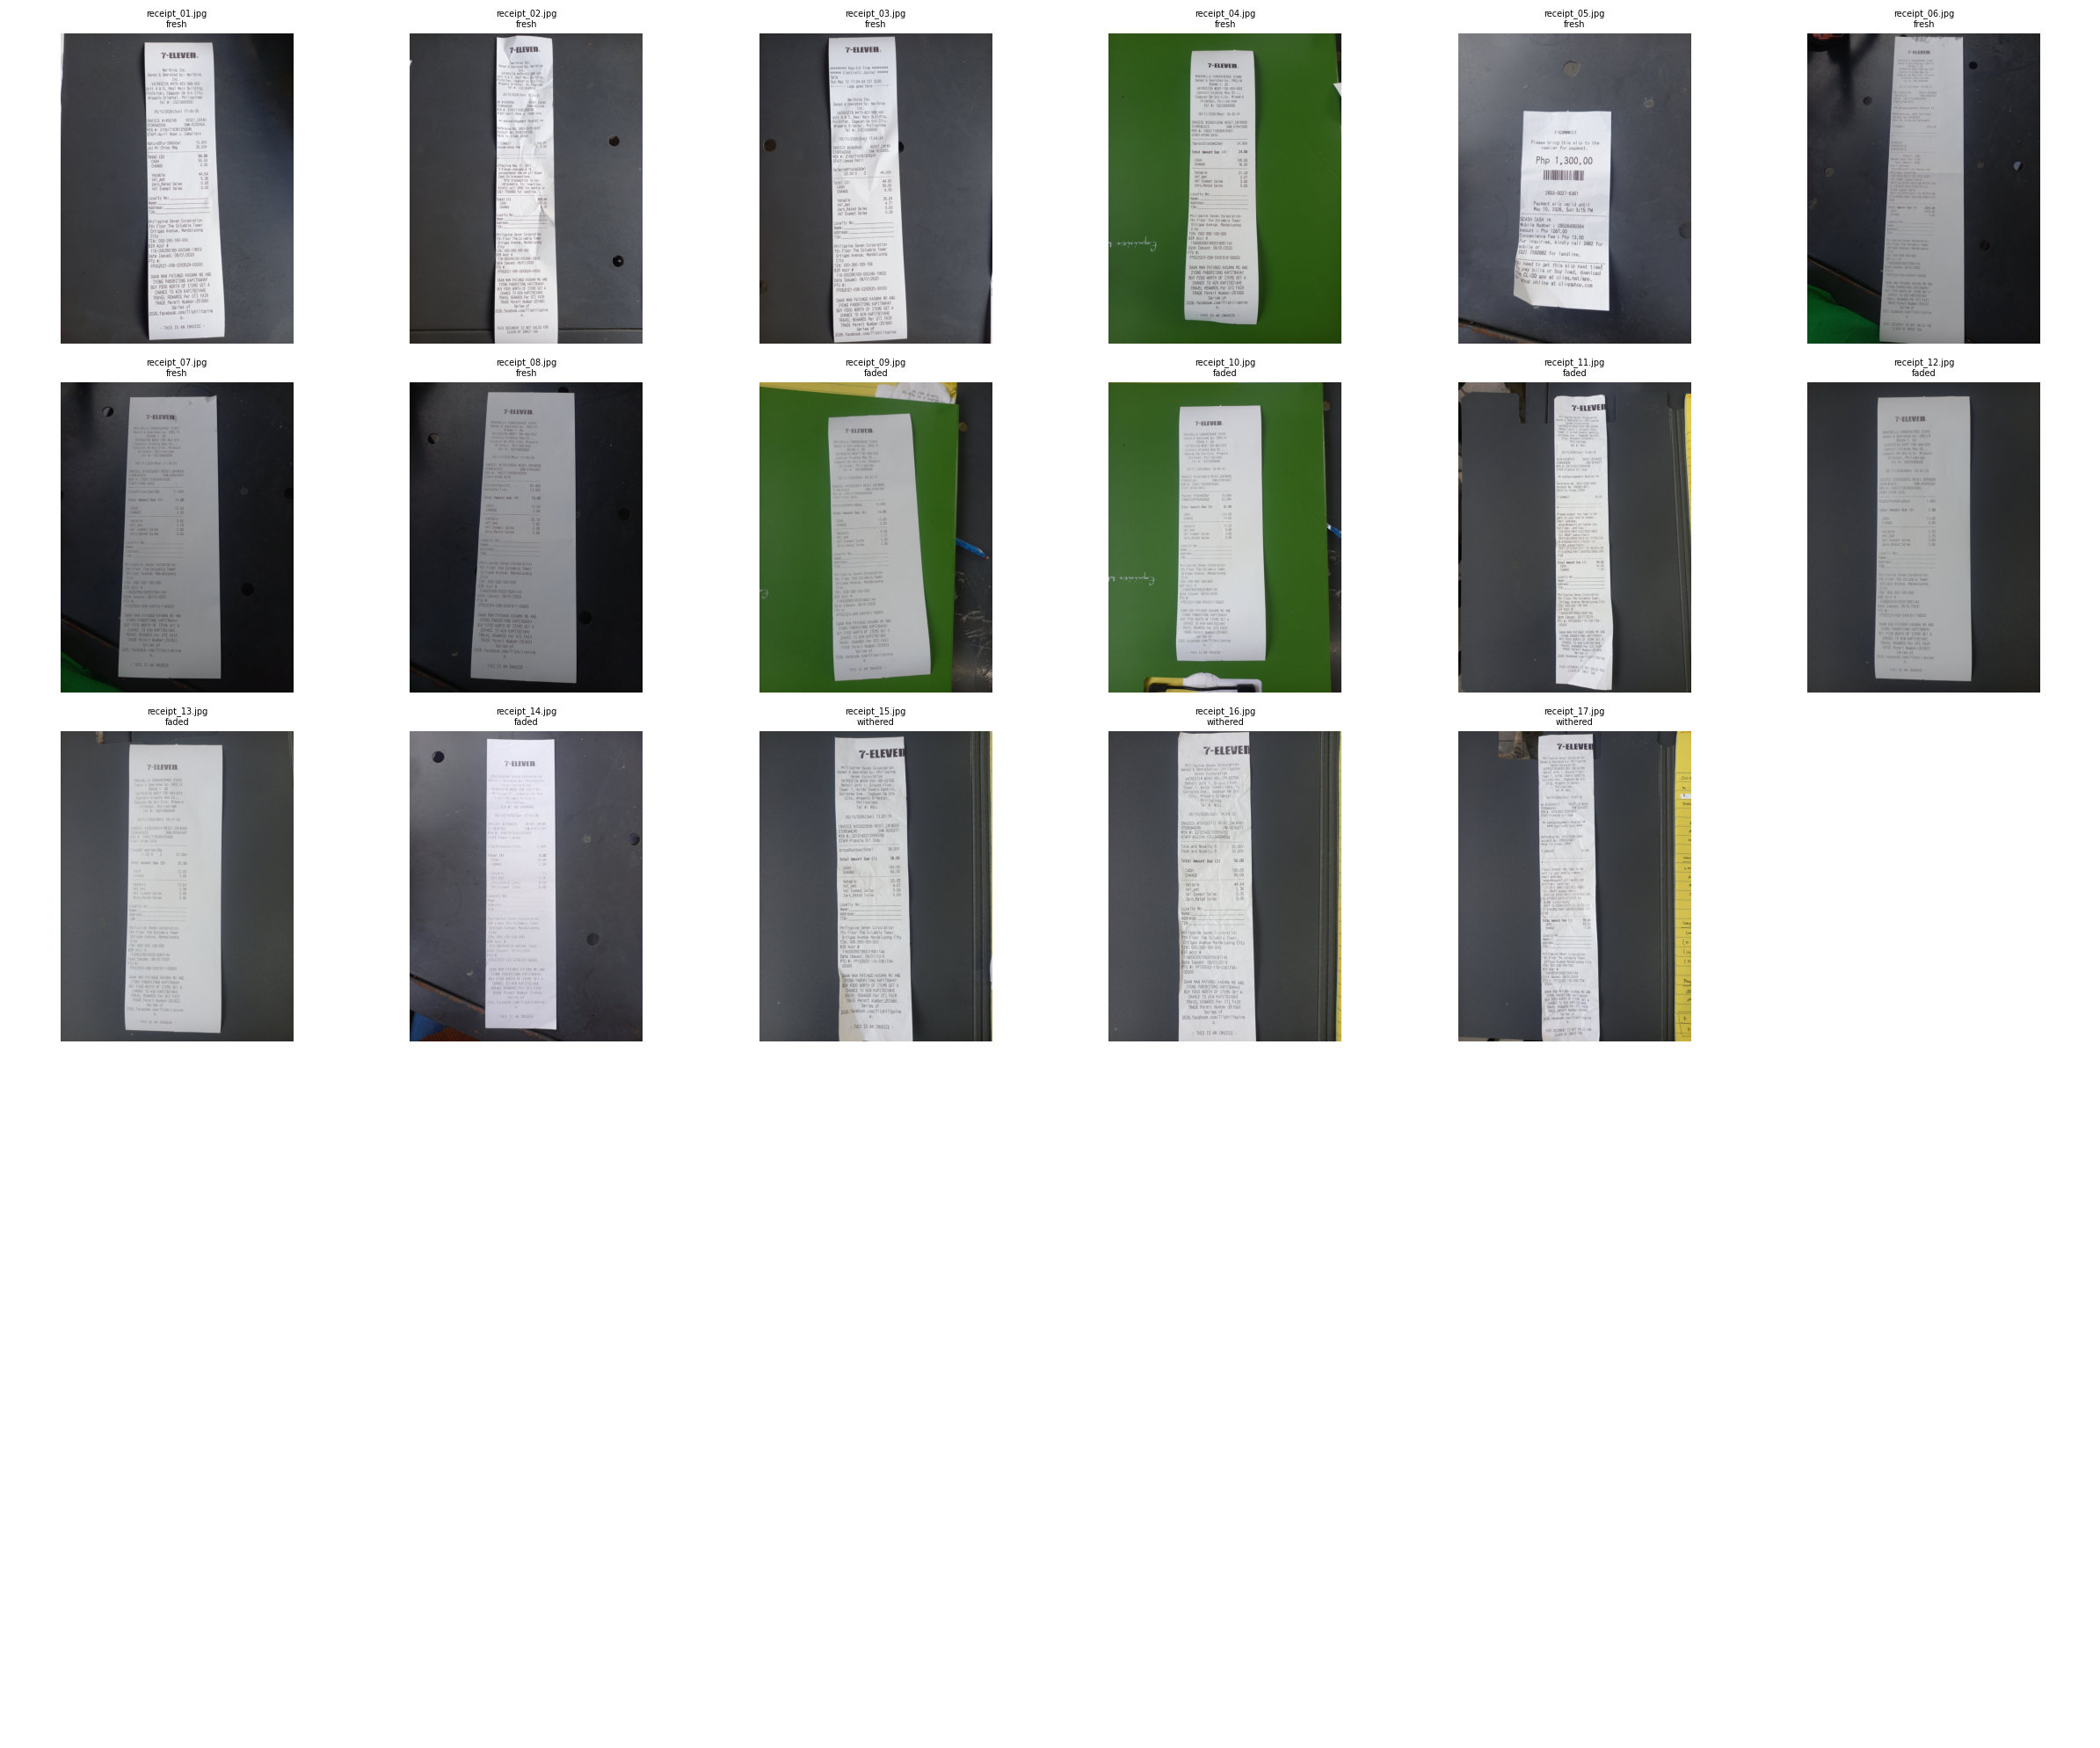

In [ ]:
fig, axes = plt.subplots(5, 6, figsize=(24, 20))
axes = axes.flatten()

for i, row in df.iterrows():
    img_path = raw_dir / row["filename"]
    img = cv2.imread(str(img_path))
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img_rgb)
        axes[i].set_title(f"{row['filename']}\n{row['condition']}", fontsize=7)
    axes[i].axis("off")

# Hide empty slots
for j in range(len(df), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig("../outputs/figures/all_receipts_preview.png")
plt.show()

In [ ]:
sizes = []

for _, row in df.iterrows():
    img_path = raw_dir / row["filename"]
    img = cv2.imread(str(img_path))
    if img is not None:
        h, w = img.shape[:2]
        sizes.append({"filename": row["filename"], "width": w, "height": h, "condition": row["condition"]})

size_df = pd.DataFrame(sizes)
print(size_df)
print(f"\nAverage width:  {size_df['width'].mean():.0f}px")
print(f"Average height: {size_df['height'].mean():.0f}px")

          filename  width  height condition
0   receipt_01.jpg   3000    4000     fresh
1   receipt_02.jpg   3000    4000     fresh
2   receipt_03.jpg   3000    4000     fresh
3   receipt_04.jpg   3000    4000     fresh
4   receipt_05.jpg   3000    4000     fresh
5   receipt_06.jpg   3000    4000     fresh
6   receipt_07.jpg   3000    4000     fresh
7   receipt_08.jpg   3000    4000     fresh
8   receipt_09.jpg   3000    4000     faded
9   receipt_10.jpg   3000    4000     faded
10  receipt_11.jpg   3000    4000     faded
11  receipt_12.jpg   3000    4000     faded
12  receipt_13.jpg   3000    4000     faded
13  receipt_14.jpg   3000    4000     faded
14  receipt_15.jpg   3000    4000  withered
15  receipt_16.jpg   3000    4000  withered
16  receipt_17.jpg   3000    4000  withered

Average width:  3000px
Average height: 4000px
